<a href="https://colab.research.google.com/github/mrrana51940/ML-projects/blob/main/DL1_cat_vs_dog_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install kaggle

In [2]:
!mkdir -p ~/.kaggle
!mv /content/kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [3]:
!kaggle competitions download -c dogs-vs-cats --force

100% 812M/812M [00:07<00:00, 115MB/s]



In [4]:
!ls

dogs-vs-cats.zip  sample_data


In [5]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
from zipfile import ZipFile

dataset = "/content/dogs-vs-cats.zip"
with ZipFile(dataset,'r') as zip:
  zip.extractall()
  print("The dataset is extracted")


The dataset is extracted


In [7]:
from zipfile import ZipFile

dataset = "/content/train.zip"
with ZipFile(dataset,'r') as zip:
  zip.extractall()
  print("The train data is extracted")

The train data is extracted


In [8]:
from zipfile import ZipFile

dataset = "/content/test1.zip"
with ZipFile(dataset,'r') as zip:
  zip.extractall()
  print("The test data is extracted")

The test data is extracted


In [9]:
import os

num_train_files = len(os.listdir('/content/train'))
print(f"Number of files in the train folder: {num_train_files}")

Number of files in the train folder: 25000


In [10]:
num_test_files = len(os.listdir('/content/test1'))
print(f"Number of files in the test folder: {num_test_files}")

Number of files in the test folder: 12500


In [11]:
print(os.listdir('/content/train'))

['dog.2618.jpg', 'cat.6756.jpg', 'cat.1694.jpg', 'dog.12236.jpg', 'dog.6483.jpg', 'cat.11712.jpg', 'cat.3414.jpg', 'cat.2646.jpg', 'dog.5909.jpg', 'dog.3297.jpg', 'dog.4778.jpg', 'cat.9766.jpg', 'cat.4809.jpg', 'cat.2043.jpg', 'dog.6954.jpg', 'dog.2989.jpg', 'cat.8067.jpg', 'cat.550.jpg', 'cat.9551.jpg', 'cat.1392.jpg', 'cat.6573.jpg', 'dog.11553.jpg', 'dog.4827.jpg', 'cat.5013.jpg', 'cat.84.jpg', 'dog.5182.jpg', 'dog.12160.jpg', 'dog.87.jpg', 'dog.3859.jpg', 'dog.8883.jpg', 'cat.2165.jpg', 'cat.10751.jpg', 'dog.4051.jpg', 'dog.1649.jpg', 'cat.6945.jpg', 'cat.9268.jpg', 'dog.10777.jpg', 'cat.1773.jpg', 'cat.11557.jpg', 'cat.3738.jpg', 'dog.7306.jpg', 'dog.9587.jpg', 'cat.10084.jpg', 'dog.12339.jpg', 'dog.477.jpg', 'dog.8717.jpg', 'dog.8791.jpg', 'dog.10124.jpg', 'dog.12177.jpg', 'cat.4195.jpg', 'cat.4643.jpg', 'dog.7059.jpg', 'cat.3200.jpg', 'dog.4896.jpg', 'cat.3805.jpg', 'dog.11921.jpg', 'dog.11687.jpg', 'cat.10557.jpg', 'dog.11118.jpg', 'cat.911.jpg', 'dog.84.jpg', 'dog.9787.jpg', '

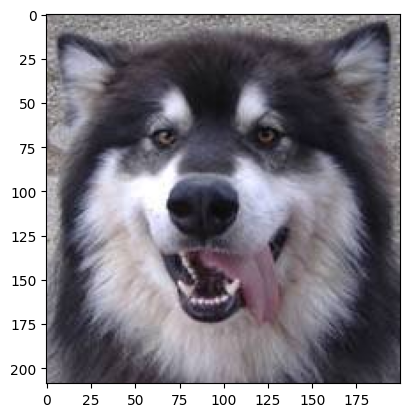

In [12]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img=mpimg.imread('/content/train/dog.5839.jpg')
plt.imshow(img)
plt.show()

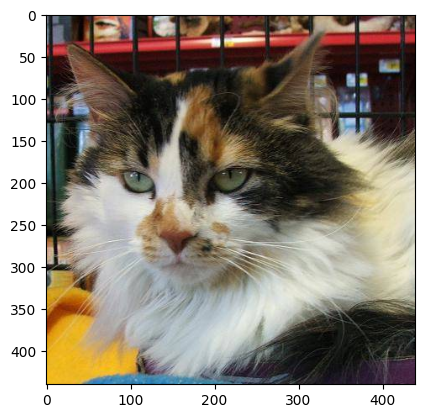

In [13]:
img=mpimg.imread('/content/train/cat.4803.jpg')
plt.imshow(img)
plt.show()

In [14]:
file_names=os.listdir('/content/train')

for i in range(10):
  print(file_names[i][:3])

dog
cat
cat
dog
dog
cat
cat
cat
dog
dog


In [15]:
dog_count=0
cat_count=0

for i in file_names:
  if i[:3]=='dog':
    dog_count+=1
  else:
    cat_count+=1
print(f"Number of dogs: {dog_count}")
print(f"Number of cats: {cat_count}")

Number of dogs: 12500
Number of cats: 12500


In [16]:
os.mkdir('/content/train resized')


In [17]:
from PIL import Image
main_path="/content/train/"
new_path="/content/train resized/"

for i in range(len(os.listdir(main_path))):
  filename=os.listdir(main_path)[i]
  img_path=main_path+filename


  img=Image.open(img_path)
  img=img.resize((224,224))
  img=img.convert('RGB')
  img.save(new_path+filename)



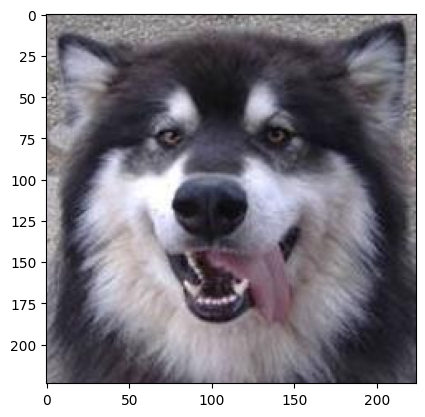

In [18]:
img=mpimg.imread('/content/train resized/dog.5839.jpg')
plt.imshow(img)
plt.show()

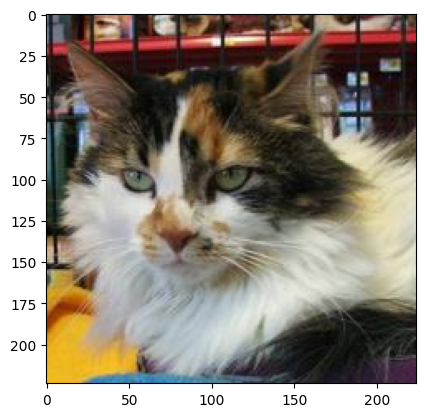

In [19]:
img=mpimg.imread('/content/train resized/cat.4803.jpg')
plt.imshow(img)
plt.show()

In [20]:
import shutil

train_dir='/content/train resized/'
cat_dir='/content/train resized/cat/'
dog_dir='/content/train resized/dog/'

os.mkdir(cat_dir)
os.mkdir(dog_dir)

for file in os.listdir(train_dir):

  path=os.path.join(train_dir,file)
  if os.path.isdir(path):
    continue


  if file.startswith('cat'):
    shutil.move(os.path.join(train_dir,file),os.path.join(cat_dir,file))
  elif file.startswith('dog'):
    shutil.move(os.path.join(train_dir,file),os.path.join(dog_dir,file))

In [21]:
import tensorflow as tf
import tensorflow_hub as hub

In [22]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_data=ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input,
    horizontal_flip=True,
    validation_split=0.2
)

train_data_gen=train_data.flow_from_directory(
    '/content/train resized/',
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    subset='training',
    shuffle=True
)
validation_data_gen=train_data.flow_from_directory(
    '/content/train resized/',
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

Found 20000 images belonging to 2 classes.
Found 5000 images belonging to 2 classes.


In [23]:
print(train_data_gen.class_indices)

{'cat': 0, 'dog': 1}


In [24]:
x_batch, y_batch = next(train_data_gen)

print(x_batch.shape)
print(y_batch.shape)

(32, 224, 224, 3)
(32,)


In [25]:
mobilenet_model = tf.keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet',
    pooling='avg'
)
mobilenet_model.trainable = True
for layer in mobilenet_model.layers[:-20]:
    layer.trainable = False

inputs = tf.keras.Input(shape=(224,224,3))
x = mobilenet_model(inputs)
outputs = tf.keras.layers.Dense(1,activation='sigmoid')(x)



9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [26]:
model = tf.keras.Model(inputs=inputs, outputs=outputs)
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 1280)           │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,053,761 (4.02 MB)

 Non-trainable params: 1,205,504 (4.60 MB)

In [27]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [28]:
model.fit(

    train_data_gen,
    validation_data=validation_data_gen,
    epochs=10
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 1287s 2s/step - accuracy: 0.9737 - loss: 0.0705 - val_accuracy: 0.5864 - val_loss: 8.1413
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 1294s 2s/step - accuracy: 0.9848 - loss: 0.0426 - val_accuracy: 0.8384 - val_loss: 1.0476
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 1233s 2s/step - accuracy: 0.9885 - loss: 0.0297 - val_accuracy: 0.9656 - val_loss: 0.2980
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 1277s 2s/step - accuracy: 0.9912 - loss: 0.0241 - val_accuracy: 0.9444 - val_loss: 0.4833
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 1284s 2s/step - accuracy: 0.9936 - loss: 0.0176 - val_accuracy: 0.9784 - val_loss: 0.1303
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 1290s 2s/step - accuracy: 0.9929 - loss: 0.0191 - val_accuracy: 0.9738 - val_loss: 0.1824
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 1326s 2s/step - accuracy: 0.9952 - loss: 0.0144 - val_accuracy: 0.9822 - val_loss: 0.1459
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 1279s 2s/step - accuracy: 0.9956 - loss: 0.0132 - 

In [29]:

model.save('/content/drive/MyDrive/DL1_cat_vs_dog_project_github_final_upload.keras')

In [30]:
import os
os.listdir('/content/drive/MyDrive')

['Colab Notebooks',
 'My photo',
 'ICT',
 'f7bb11c846734daab809c2e68ae61839 (1).pdf',
 '86747c4b2e5c87f759e81c5b003cd459.pdf',
 '86747c4b2e5c87f759e81c5b003cd459-Copy.pdf',
 '86747c4b2e5c87f759e81c5b003cd459-Copy 2.pdf',
 'Classroom',
 'MATH_-1101review (1).gdoc',
 'MATH_-1101review.gdoc',
 'function_limite_derivative (1).gdoc',
 'function_limite_derivative.gdoc',
 'out. (1) (1).jpeg.jpg',
 'out. (1).jpeg.jpg',
 'Musfiq rana - FUNCTION AND RECCURSION (PRACTICE PROBLEM) (1).gdoc',
 'Musfiq rana - FUNCTION AND RECCURSION (PRACTICE PROBLEM).gdoc',
 'Musfiq rana - PRACTICE PROBLEM (STRING) (1).gdoc',
 'Musfiq rana - PRACTICE PROBLEM (STRING).gdoc',
 'Assignment 2.docx',
 'Operators and Expressions.gdoc',
 'inbound69745917006493907.jpg',
 'Musfiq rana - Assignment 1: Write down the properties of Fourier Series. .gdoc',
 'unknown',
 'Class Math (2118033).pdf',
 'AlablistCode (3)',
 'AlablistCode (2)',
 'AlablistCode (1)',
 'AlablistCode',
 'inbound8677677297441001354.jpg',
 'Untitled design-

In [31]:
import tensorflow as tf
model=tf.keras.models.load_model('/content/drive/MyDrive/DL1_cat_vs_dog_project_github_final_upload.keras')

Saving 3302cad8-8bed-44d0-aa4e-fe52cad77dfe.jpg to 3302cad8-8bed-44d0-aa4e-fe52cad77dfe.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
Raw prediction: [[3.8552603e-06]]
The image is of a cat
Predicted probability :  99.99961447397254 %


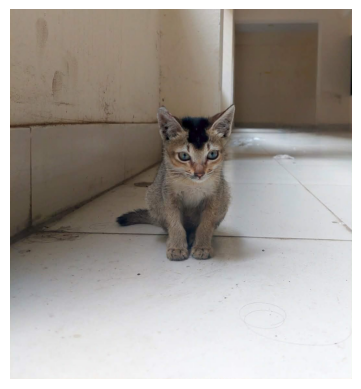

In [33]:
from PIL import Image
import numpy as np
from google.colab import files

upload_file=files.upload()

for filename in upload_file.keys():
  path=filename

img=Image.open(path)
img=img.resize((224,224))
img=img.convert('RGB')

img=np.array(img)
img=np.expand_dims(img,axis=0)

img=tf.keras.applications.mobilenet_v2.preprocess_input(img)

pred=model.predict(img)

print("Raw prediction:", pred)

pred_class = 'dog' if pred[0][0] > 0.5 else 'cat'
print(f"The image is of a {pred_class}")
print("Predicted probability : ", float(pred[0][0])*100 if pred_class=='dog' else (1-float(pred[0][0]))*100, "%")

img=mpimg.imread(path)
plt.imshow(img)
plt.axis('off')
plt.show()